In [1]:
import io, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt, soundfile as sf
import librosa
from scipy.fft import dct
from datasets import load_dataset, Audio
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

LABEL_HOP = 512          # each reference label covers 512 samples = 32 ms at 16 kHz

In [2]:
dataset = load_dataset("guynich/librispeech_asr_test_vad", split="test.clean")
dataset = dataset.cast_column("audio", Audio(decode=False))

file_names = dataset["file"]
speaker_of = [os.path.basename(str(f)).split("-")[0] for f in file_names]

N_PER_SPEAKER = 3
rng = np.random.default_rng(42)
selected = []
for speaker in sorted(set(speaker_of)):
    idx = [i for i, s in enumerate(speaker_of) if s == speaker]
    selected += list(rng.choice(idx, size=min(N_PER_SPEAKER, len(idx)), replace=False))

recordings = []
for i in selected:
    sample = dataset[int(i)]
    audio = sample["audio"]
    source = io.BytesIO(audio["bytes"]) if audio["bytes"] is not None else audio["path"]
    y, sr = sf.read(source)
    if y.ndim > 1:
        y = y.mean(axis=1)
    reference = np.asarray(sample["speech"], dtype=int)
    valid = np.asarray(sample["confidence"], dtype=int) == 1
    n_blocks = len(reference)
    y = np.pad(y, (0, max(0, n_blocks * LABEL_HOP - len(y))))[:n_blocks * LABEL_HOP]
    recordings.append({"id": os.path.basename(str(sample["file"])), "speaker": speaker_of[i], "y": y,
                       "reference": reference, "valid": valid, "n_blocks": n_blocks})

# Split by speaker: models are fitted on one half of the speakers and tested on the other half
speakers = sorted(set(r["speaker"] for r in recordings))
train_speakers = set(np.random.default_rng(7).permutation(speakers)[:len(speakers) // 2])
for r in recordings:
    r["split"] = "train" if r["speaker"] in train_speakers else "test"

print("Speakers:", len(speakers), "| Recordings:", len(recordings),
      "| Train recordings:", sum(r["split"] == "train" for r in recordings),
      "| Test recordings:", sum(r["split"] == "test" for r in recordings))

Speakers: 40 | Recordings: 120 | Train recordings: 60 | Test recordings: 60


In [3]:
def fit_length(x, n, rng):
    """Repeat or crop a signal to exactly n samples."""
    if len(x) < n:
        x = np.tile(x, int(np.ceil(n / len(x))))
    start = rng.integers(0, len(x) - n + 1)
    return x[start:start + n]

def make_noise(n, kind, rng, own_index):
    """white | fluctuating: pink noise with a drifting level | babble: four other talkers mixed together."""
    if kind == "babble":
        same_split = [j for j, other in enumerate(recordings)
                      if other["split"] == recordings[own_index]["split"] and other["speaker"] != recordings[own_index]["speaker"]]
        total = np.zeros(n)
        for j in rng.choice(same_split, size=4, replace=False):
            voice = fit_length(recordings[j]["y"], n, rng)
            total += voice / (np.sqrt(np.mean(voice ** 2)) + 1e-10)
        return total
    white = rng.normal(size=n)
    if kind == "white":
        return white
    spectrum = np.fft.rfft(white)
    freqs = np.fft.rfftfreq(n)
    freqs[0] = freqs[1]
    pink = np.fft.irfft(spectrum / np.sqrt(freqs), n=n)
    control = rng.normal(size=int(n / sr * 5) + 2) * 4.0
    gain_db = np.interp(np.arange(n), np.linspace(0, n, len(control)), control)
    return pink * 10 ** (gain_db / 20)

CONDITIONS = {"clean": None, "white 10 dB": ("white", 10), "fluctuating 10 dB": ("fluctuating", 10),
              "babble 10 dB": ("babble", 10)}

for index, r in enumerate(recordings):
    mask = np.repeat(r["reference"] == 1, LABEL_HOP)
    r["signals"] = {}
    for name, setting in CONDITIONS.items():
        if setting is None:
            r["signals"][name] = r["y"]
            continue
        kind, snr_db = setting
        noise = make_noise(len(r["y"]), kind, np.random.default_rng(index), index)
        power = np.mean(r["y"][mask] ** 2) if mask.any() else np.mean(r["y"] ** 2)
        r["signals"][name] = r["y"] + noise * np.sqrt(power / (np.mean(noise ** 2) * 10 ** (snr_db / 10)))
print("Conditions:", list(CONDITIONS))

Conditions: ['clean', 'white 10 dB', 'fluctuating 10 dB', 'babble 10 dB']


In [4]:
N_FFT = 512
WINDOW = np.hanning(LABEL_HOP)
FREQS = np.fft.rfftfreq(N_FFT, d=1 / 16000)
MEL = librosa.filters.mel(sr=16000, n_fft=N_FFT, n_mels=26)

GROUPS = {
    "energy": ["rel_energy"],
    "zcr": ["zcr"],
    "spectral": ["centroid", "rolloff", "flatness", "flux", "band_ratio"],
    "voicing": ["harmonicity"],
    "mfcc": [f"mfcc{i}" for i in range(1, 13)],
}
FEATURES = [name for group in GROUPS.values() for name in group]

def extract(signal, n_blocks):
    """One row of features per 32 ms label block."""
    blocks = signal[:n_blocks * LABEL_HOP].reshape(n_blocks, LABEL_HOP)

    # Energy relative to the recording's own noise floor (robust floor from EXP-04)
    db = 10 * np.log10(np.mean(blocks ** 2, axis=1) + 1e-20)
    clipped = np.maximum(db, np.percentile(db, 95) - 60)
    rel_energy = clipped - np.percentile(clipped, 10)

    # Zero crossing rate: how often the waveform changes sign
    signs = np.signbit(blocks)
    zcr = np.mean(signs[:, 1:] != signs[:, :-1], axis=1)

    # Spectrum-based features
    mag = np.abs(np.fft.rfft(blocks * WINDOW, n=N_FFT, axis=1))
    power = mag ** 2
    total = mag.sum(axis=1) + 1e-10
    centroid = (mag * FREQS).sum(axis=1) / total                               # "centre of mass" of the spectrum
    cumulative = np.cumsum(mag, axis=1)
    rolloff = FREQS[np.argmax(cumulative >= 0.85 * cumulative[:, -1:], axis=1)]  # frequency below which 85% lies
    flatness = np.exp(np.mean(np.log(power + 1e-10), axis=1)) / (np.mean(power, axis=1) + 1e-10)  # 1 = noise-like
    shape = mag / total[:, None]
    flux = np.zeros(n_blocks)
    flux[1:] = np.sqrt(np.sum(np.diff(shape, axis=0) ** 2, axis=1))            # how fast the spectrum changes
    band = (FREQS >= 300) & (FREQS <= 3000)
    band_ratio = power[:, band].sum(axis=1) / (power.sum(axis=1) + 1e-10)      # share of power in the speech band

    # Voicing: strength of the periodicity at pitch lags (60-400 Hz)
    centred = blocks - blocks.mean(axis=1, keepdims=True)
    autocorr = np.fft.irfft(np.abs(np.fft.rfft(centred, n=2 * LABEL_HOP, axis=1)) ** 2, axis=1)
    harmonicity = autocorr[:, 40:267].max(axis=1) / (autocorr[:, 0] + 1e-10)

    # MFCC: compact description of the spectral envelope (coefficient 0 is dropped, it mirrors energy)
    mfcc = dct(np.log(power @ MEL.T + 1e-10), type=2, norm="ortho", axis=1)[:, 1:13]

    return np.column_stack([rel_energy, zcr, centroid, rolloff, flatness, flux, band_ratio, harmonicity, mfcc])

tables = []
for r in recordings:
    for condition, signal in r["signals"].items():
        frame = pd.DataFrame(extract(signal, r["n_blocks"]), columns=FEATURES)
        frame["label"] = r["reference"]; frame["valid"] = r["valid"]
        frame["speaker"] = r["speaker"]; frame["split"] = r["split"]; frame["condition"] = condition
        tables.append(frame)
data = pd.concat(tables, ignore_index=True)
data = data[data["valid"]].drop(columns="valid").reset_index(drop=True)
train, test = data[data["split"] == "train"], data[data["split"] == "test"]
print("Feature table:", data.shape, "| Train blocks:", len(train), "| Test blocks:", len(test),
      "| Speech share:", data["label"].mean().round(3))

Feature table: (120580, 24) | Train blocks: 59296 | Test blocks: 61284 | Speech share: 0.834


In [5]:
def miss_at_far(labels, scores, far=0.05):
    """Miss rate when the threshold is set so that 5% of the non-speech blocks are accepted."""
    threshold = np.quantile(scores[labels == 0], 1 - far)
    return float(np.mean(scores[labels == 1] <= threshold))

rows = []
for feature in FEATURES:
    for condition in CONDITIONS:
        tr = train[train["condition"] == condition]
        te = test[test["condition"] == condition]
        sign = 1 if roc_auc_score(tr["label"], tr[feature]) >= 0.5 else -1     # direction learned on the train speakers
        rows.append({"feature": feature, "condition": condition,
                     "AUC": roc_auc_score(te["label"], sign * te[feature]),
                     "direction": "higher = speech" if sign == 1 else "lower = speech"})
single = pd.DataFrame(rows)
single_auc = single.pivot(index="feature", columns="condition", values="AUC").loc[FEATURES, list(CONDITIONS)]
single_auc["mean"] = single_auc.mean(axis=1)
for condition in CONDITIONS:
    print(f"Single-feature ROC-AUC — {condition} (test speakers)")
    display(single_auc[[condition]].sort_values(condition, ascending=False).round(3))
display(single.pivot(index="feature", columns="condition", values="direction").loc[
    ["zcr", "centroid", "flatness", "harmonicity"], list(CONDITIONS)])

Single-feature ROC-AUC — clean (test speakers)
Single-feature ROC-AUC — white 10 dB (test speakers)
Single-feature ROC-AUC — fluctuating 10 dB (test speakers)
Single-feature ROC-AUC — babble 10 dB (test speakers)


condition,clean
feature,
rel_energy,0.981
flatness,0.721
harmonicity,0.705
mfcc1,0.704
mfcc8,0.693
band_ratio,0.684
flux,0.673
mfcc11,0.668
mfcc7,0.665


condition,white 10 dB
feature,
rel_energy,0.967
flatness,0.932
harmonicity,0.922
flux,0.882
zcr,0.877
rolloff,0.867
centroid,0.862
mfcc1,0.843
mfcc2,0.794


condition,fluctuating 10 dB
feature,
rel_energy,0.885
harmonicity,0.837
rolloff,0.828
flatness,0.779
mfcc1,0.759
centroid,0.755
flux,0.724
mfcc3,0.675
mfcc6,0.662


condition,babble 10 dB
feature,
rel_energy,0.894
harmonicity,0.571
flatness,0.563
zcr,0.547
flux,0.547
mfcc1,0.535
rolloff,0.534
centroid,0.533
mfcc10,0.521


condition,clean,white 10 dB,fluctuating 10 dB,babble 10 dB
feature,,,,
zcr,lower = speech,lower = speech,lower = speech,lower = speech
centroid,lower = speech,lower = speech,lower = speech,lower = speech
flatness,lower = speech,lower = speech,lower = speech,lower = speech
harmonicity,higher = speech,higher = speech,higher = speech,higher = speech


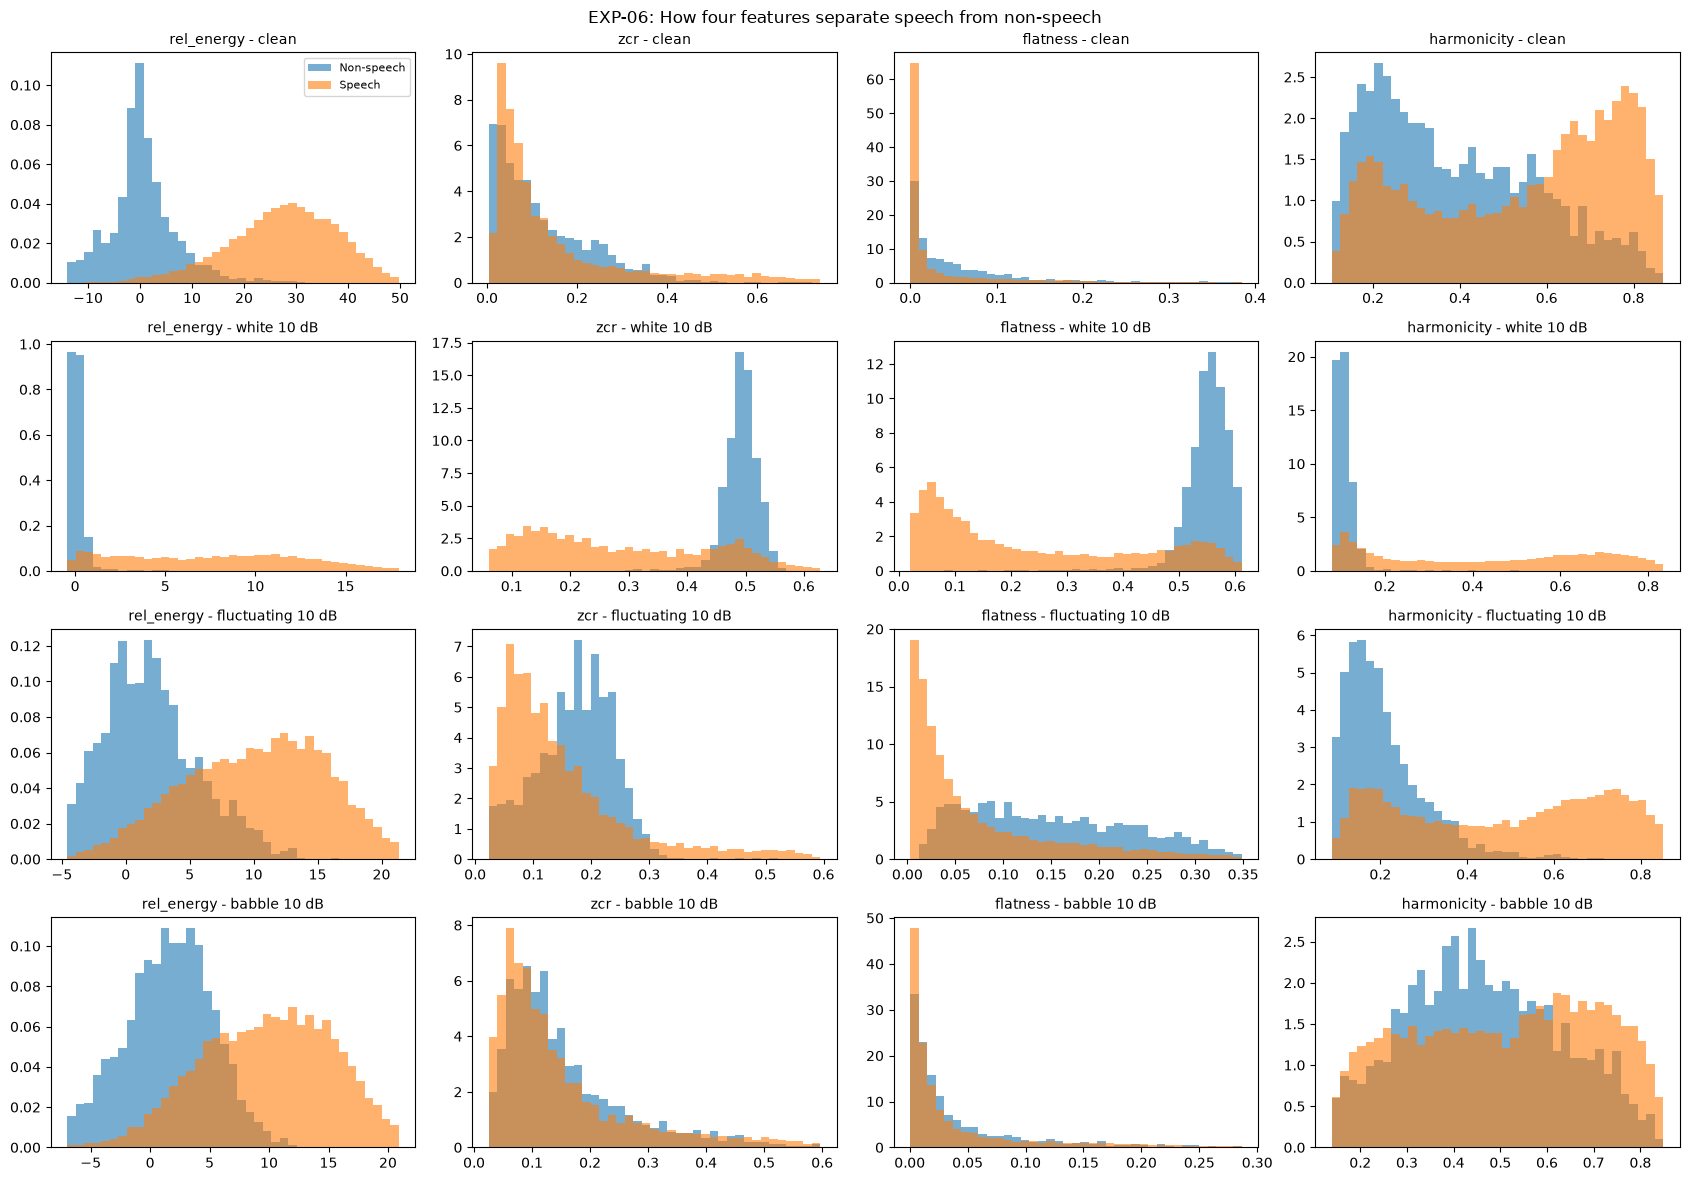

In [6]:
show = ["rel_energy", "zcr", "flatness", "harmonicity"]
fig, axes = plt.subplots(len(CONDITIONS), len(show), figsize=(17, 3 * len(CONDITIONS)))
for row, condition in enumerate(CONDITIONS):
    part = test[test["condition"] == condition]
    for col, feature in enumerate(show):
        ax = axes[row, col]
        low, high = np.percentile(part[feature], [1, 99])
        bins = np.linspace(low, high, 40)
        ax.hist(part.loc[part["label"] == 0, feature], bins=bins, alpha=0.6, density=True, label="Non-speech")
        ax.hist(part.loc[part["label"] == 1, feature], bins=bins, alpha=0.6, density=True, label="Speech")
        ax.set_title(f"{feature} - {condition}", fontsize=10)
axes[0, 0].legend(fontsize=8)
plt.suptitle("EXP-06: How four features separate speech from non-speech"); plt.tight_layout(); plt.show()
# Actual feature values, separate from AUC/model scores.
feature_value_summary = data.groupby(["split", "condition", "label"])[FEATURES].agg(["median", lambda x: x.quantile(0.1), lambda x: x.quantile(0.9)])
feature_value_summary.columns = [f"{feature}_{stat}".replace("<lambda_0>", "p10").replace("<lambda_1>", "p90") for feature, stat in feature_value_summary.columns]


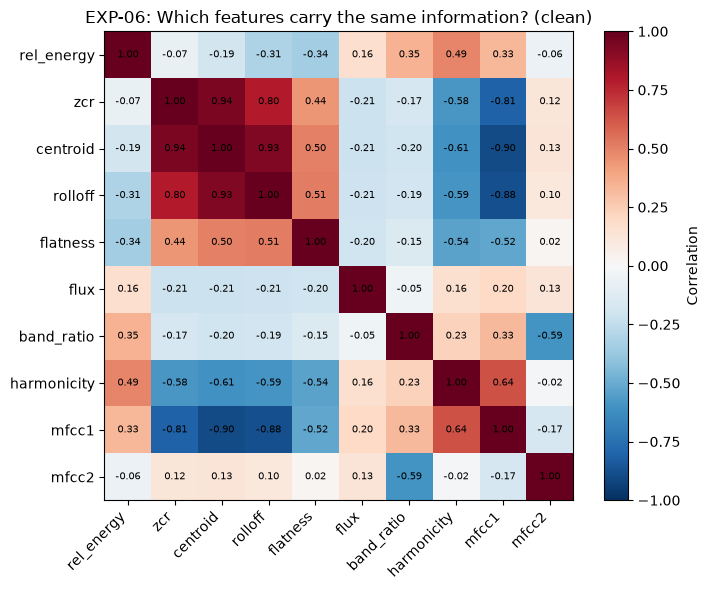

In [7]:
compact = [f for f in FEATURES if not f.startswith("mfcc")] + ["mfcc1", "mfcc2"]
corr = test[test["condition"] == "clean"][compact].corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
image = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(compact))); ax.set_xticklabels(compact, rotation=45, ha="right")
ax.set_yticks(range(len(compact))); ax.set_yticklabels(compact)
for i in range(len(compact)):
    for j in range(len(compact)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(image, label="Correlation"); plt.title("EXP-06: Which features carry the same information? (clean)")
plt.tight_layout(); plt.show()

In [8]:
def fit_and_score(feature_names, kind="lr", train_part=None):
    """Fit on the train speakers (all conditions pooled unless train_part is given), score each condition on the test speakers."""
    tr = train if train_part is None else train_part
    if kind == "lr":
        model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
    else:
        model = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=10,
                                       class_weight="balanced_subsample", n_jobs=-1, random_state=0)
    model.fit(tr[feature_names].values, tr["label"].values)
    out = {}
    for condition in CONDITIONS:
        te = test[test["condition"] == condition]
        scores = model.predict_proba(te[feature_names].values)[:, 1]
        out[condition] = (roc_auc_score(te["label"], scores), miss_at_far(te["label"].values, scores))
    return out

def as_tables(results):
    auc = pd.DataFrame({name: {c: v[0] for c, v in res.items()} for name, res in results.items()}).T[list(CONDITIONS)]
    miss = pd.DataFrame({name: {c: v[1] for c, v in res.items()} for name, res in results.items()}).T[list(CONDITIONS)]
    auc["mean"] = auc.mean(axis=1); miss["mean"] = miss.mean(axis=1)
    return auc, miss

steps = {}
names = []
for group in ["energy", "zcr", "spectral", "voicing", "mfcc"]:
    names = names + GROUPS[group]
    steps["energy" if group == "energy" else f"+ {group}"] = fit_and_score(list(names))
steps["old EXP-06 set (energy + zcr + centroid)"] = fit_and_score(["rel_energy", "zcr", "centroid"])
cumulative_auc, cumulative_miss = as_tables(steps)
print("AUC"); display(cumulative_auc.round(3))
print("Oracle miss at 5% FAR (threshold chosen on test; not a fixed-threshold test result)"); display(cumulative_miss.round(3))

AUC
Oracle miss at 5% FAR (threshold chosen on test; not a fixed-threshold test result)


,clean,white 10 dB,fluctuating 10 dB,babble 10 dB,mean
energy,0.981,0.967,0.885,0.894,0.932
+ zcr,0.981,0.959,0.894,0.900,0.934
+ spectral,0.983,0.968,0.899,0.904,0.938
+ voicing,0.982,0.966,0.912,0.892,0.938
+ mfcc,0.985,0.954,0.916,0.896,0.938
old EXP-06 set (energy + zcr + centroid),0.981,0.963,0.888,0.902,0.934


,clean,white 10 dB,fluctuating 10 dB,babble 10 dB,mean
energy,0.070,0.078,0.397,0.324,0.217
+ zcr,0.074,0.101,0.371,0.312,0.214
+ spectral,0.066,0.088,0.358,0.324,0.209
+ voicing,0.066,0.094,0.308,0.337,0.201
+ mfcc,0.054,0.121,0.275,0.331,0.195
old EXP-06 set (energy + zcr + centroid),0.074,0.091,0.388,0.305,0.214


In [9]:
leave_out = {"all features": fit_and_score(FEATURES)}
for group in GROUPS:
    kept = [f for f in FEATURES if f not in GROUPS[group]]
    leave_out[f"without {group}"] = fit_and_score(kept)
leave_auc, leave_miss = as_tables(leave_out)
print("Oracle miss at 5% FAR (threshold chosen on test)"); display(leave_miss.round(3))
print("Increase in miss rate when a group is removed")
display((leave_miss - leave_miss.loc["all features"]).drop("all features").round(3))

Oracle miss at 5% FAR (threshold chosen on test)
Increase in miss rate when a group is removed


,clean,white 10 dB,fluctuating 10 dB,babble 10 dB,mean
all features,0.054,0.121,0.275,0.331,0.195
without energy,0.281,0.173,0.246,0.920,0.405
without zcr,0.056,0.120,0.285,0.337,0.199
without spectral,0.065,0.127,0.275,0.333,0.200
without voicing,0.053,0.122,0.284,0.324,0.196
without mfcc,0.066,0.094,0.308,0.337,0.201


,clean,white 10 dB,fluctuating 10 dB,babble 10 dB,mean
without energy,0.226,0.052,-0.029,0.589,0.210
without zcr,0.002,-0.001,0.009,0.006,0.004
without spectral,0.011,0.007,-0.000,0.002,0.005
without voicing,-0.001,0.001,0.009,-0.007,0.000
without mfcc,0.011,-0.027,0.033,0.006,0.006


In [10]:
compare = {
    "LR, all features": leave_out["all features"],
    "RF, all features": fit_and_score(FEATURES, kind="rf"),
    "LR, energy only": steps["energy"],
    "RF, energy only": fit_and_score(GROUPS["energy"], kind="rf"),
    "LR, all features, trained on clean only": fit_and_score(FEATURES, train_part=train[train["condition"] == "clean"]),
}
compare_auc, compare_miss = as_tables(compare)
print("AUC"); display(compare_auc.round(3))
print("Oracle miss at 5% FAR (threshold chosen on test)"); display(compare_miss.round(3))

AUC
Oracle miss at 5% FAR (threshold chosen on test)


,clean,white 10 dB,fluctuating 10 dB,babble 10 dB,mean
"LR, all features",0.985,0.954,0.916,0.896,0.938
"RF, all features",0.980,0.981,0.954,0.904,0.955
"LR, energy only",0.981,0.967,0.885,0.894,0.932
"RF, energy only",0.972,0.961,0.877,0.886,0.924
"LR, all features, trained on clean only",0.985,0.951,0.932,0.854,0.930


,clean,white 10 dB,fluctuating 10 dB,babble 10 dB,mean
"LR, all features",0.054,0.121,0.275,0.331,0.195
"RF, all features",0.077,0.044,0.141,0.286,0.137
"LR, energy only",0.070,0.078,0.397,0.324,0.217
"RF, energy only",0.131,0.090,0.415,0.359,0.249
"LR, all features, trained on clean only",0.062,0.124,0.220,0.424,0.207


In [11]:
# Exports are placed after the final RF comparison below.


In [12]:
# The same question for the better model: random forest trained on clean audio only
extra = {"RF, all features": compare["RF, all features"],
         "RF, all features, trained on clean only": fit_and_score(FEATURES, kind="rf",
                                                                  train_part=train[train["condition"] == "clean"])}
extra_auc, extra_miss = as_tables(extra)
print("Oracle miss at 5% FAR (threshold chosen on test)")
display(extra_miss.round(3))

Oracle miss at 5% FAR (threshold chosen on test)


,clean,white 10 dB,fluctuating 10 dB,babble 10 dB,mean
"RF, all features",0.077,0.044,0.141,0.286,0.137
"RF, all features, trained on clean only",0.053,0.393,0.276,0.403,0.281


In [13]:
os.makedirs("../results", exist_ok=True)
single_auc.to_csv("../results/exp06_single_feature_auc.csv")
cumulative_miss.to_csv("../results/exp06_cumulative_groups_miss.csv")
leave_miss.to_csv("../results/exp06_leave_one_group_out_miss.csv")
compare_miss.to_csv("../results/exp06_models_miss.csv")
cumulative_auc.to_csv("../results/exp06_cumulative_groups_auc.csv")
leave_auc.to_csv("../results/exp06_leave_one_group_out_auc.csv")
compare_auc.to_csv("../results/exp06_models_auc.csv")
extra_auc.to_csv("../results/exp06_rf_clean_vs_mixed_auc.csv")
extra_miss.to_csv("../results/exp06_rf_clean_vs_mixed_oracle_miss.csv")
feature_value_summary.to_csv("../results/exp06_feature_values.csv")
for condition in CONDITIONS:
    slug = condition.replace(" ", "_")
    single_auc[[condition]].to_csv(f"../results/exp06_single_feature_auc_{slug}.csv")
print("Saved all tables, including the final RF comparison.")

Saved all tables, including the final RF comparison.
